In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import Perceptron as SkPerceptron

In [ ]:
np.random.seed(42)

In [ ]:
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'figure.titleweight': 'bold',
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'savefig.dpi': 200,
    'figure.dpi': 100,
})

def save_show(name, fig=None):
    path = os.path.join(PLOT_DIR, name + ".png")
    (fig or plt.gcf()).savefig(path, format="png", dpi=600, bbox_inches="tight")
    print("Saved ->", path)
    plt.show()

Task 1: Dataset Exploration

In [ ]:
cols = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
df = pd.read_csv("data_banknote_authentication.txt", header=None, names=cols)

In [ ]:
print("First 5 Samples")
print(df.head())

First 5 Samples
   Variance  Skewness  Curtosis  Entropy  Class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0


In [ ]:
print("Dataset Dimensions:", df.shape)

Dataset Dimensions: (1372, 5)


In [ ]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [ ]:
print("Descriptive Statistics")
print(df.describe())

Descriptive Statistics
          Variance     Skewness     Curtosis      Entropy        Class
count  1372.000000  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657     0.444606
std       2.842763     5.869047     4.310030     2.101013     0.497103
min      -7.042100   -13.773100    -5.286100    -8.548200     0.000000
25%      -1.773000    -1.708200    -1.574975    -2.413450     0.000000
50%       0.496180     2.319650     0.616630    -0.586650     0.000000
75%       2.821475     6.814625     3.179250     0.394810     1.000000
max       6.824800    12.951600    17.927400     2.449500     1.000000


In [ ]:
print("\nClass distribution (0 = Authentic, 1 = Forged):")
print(df['Class'].value_counts())


Class distribution (0 = Authentic, 1 = Forged):
Class
0    762
1    610
Name: count, dtype: int64


Task 2: Exploratory Data Analysis

'save_show("01_feature_histograms")'

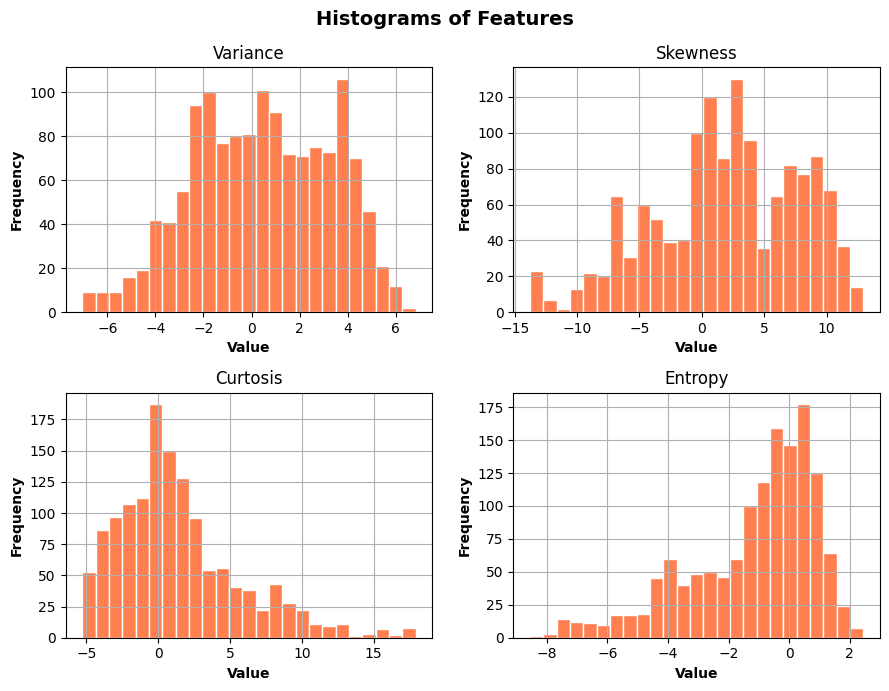

In [ ]:
feats = cols[:-1]

axes = df[feats].hist(figsize=(9, 7), bins=25, color="coral", edgecolor="white")
for ax in axes.flatten():
    ax.set_xlabel("Value", fontweight="bold")
    ax.set_ylabel("Frequency", fontweight="bold")
plt.suptitle("Histograms of Features", fontweight="bold", fontsize=14)
plt.tight_layout()
'''save_show("01_feature_histograms")'''

Saved -> plots/02_correlation_heatmap.png


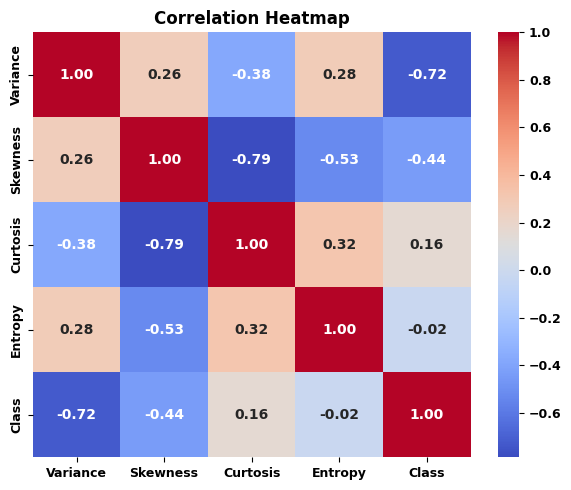

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"weight": "bold"})
plt.title("Correlation Heatmap")
plt.tight_layout()
save_show("02_correlation_heatmap")

Saved -> plots/03_scatter_variance_skewness.png


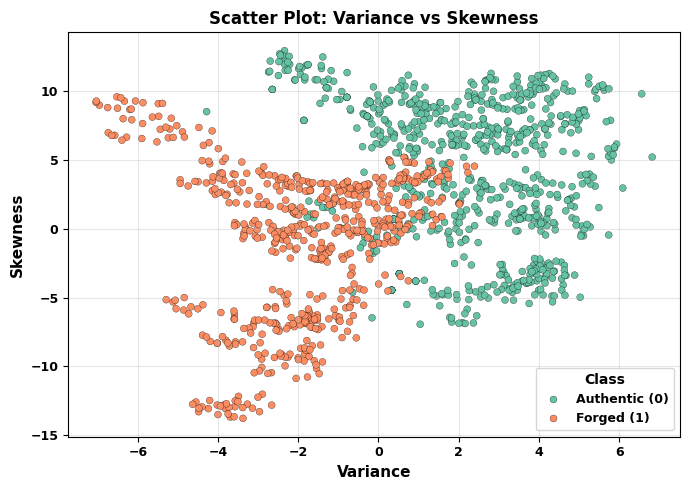

In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(data=df, x="Variance", y="Skewness", hue="Class",
                     palette="Set2", s=25, edgecolor="k", linewidth=0.2)
ax.set_title("Scatter Plot: Variance vs Skewness")
ax.set_xlabel("Variance")
ax.set_ylabel("Skewness")

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Authentic (0)", "Forged (1)"], title="Class")

plt.grid(True, alpha=0.3)
plt.tight_layout()
save_show("03_scatter_variance_skewness")

Saved -> plots/04_boxplots.png


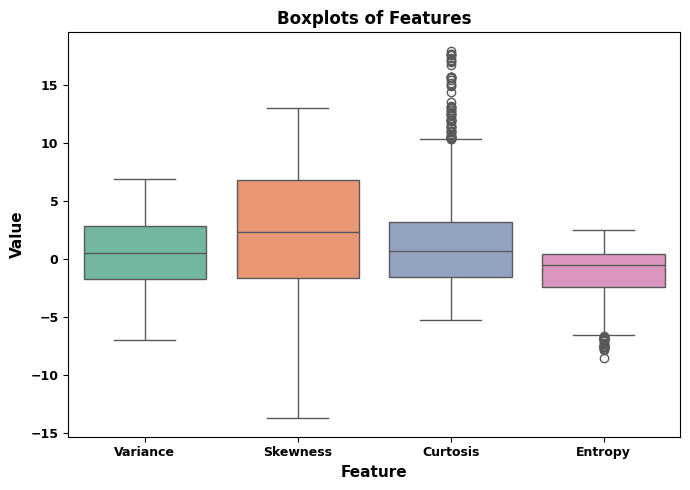

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df[feats], palette="Set2")
plt.title("Boxplots of Features")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.tight_layout()
save_show("04_boxplots")

Task 3: Data Preprocessing

In [ ]:
X = df[feats].values
y = df["Class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("y_train:", y_train.shape, " y_test:", y_test.shape)
print("\nMean after scaling:", np.round(X_scaled.mean(axis=0), 3))
print("Std  after scaling:", np.round(X_scaled.std(axis=0), 3))

X_train: (1097, 4)  X_test: (275, 4)
y_train: (1097,)  y_test: (275,)

Mean after scaling: [ 0.  0.  0. -0.]
Std  after scaling: [1. 1. 1. 1.]


Task 4: Perceptron Implementation

In [ ]:
def step(z):
    return 1 if z >= 0 else 0

def predict(X, weights, bias):
    return np.array([step(np.dot(x, weights) + bias) for x in X])

def train(X, y, lr=0.01, epochs=50):
    weights = np.zeros(X.shape[1])   # weight initialization
    bias = 0.0                       # bias initialization
    history = []

    for epoch in range(epochs):
        errors = 0
        for x, target in zip(X, y):
            z = np.dot(x, weights) + bias        # forward propagation
            prediction = step(z)
            error = target - prediction          # (y - y_hat)
            weights = weights + lr * error * x   # weight update rule
            bias = bias + lr * error             # bias update rule
            if error != 0:
                errors += 1
        history.append({"Epoch": epoch + 1, "Errors": errors,
                        "Bias": bias, **{f"w{i+1}": weights[i] for i in range(len(weights))}})
        if errors == 0:
            break
    return weights, bias, history

Task 5: Model Training

In [ ]:
LR = 0.05
EPOCHS = 20

weights, bias, history = train(X_train, y_train, lr=LR, epochs=EPOCHS)

history_df = pd.DataFrame(history)
print(history_df)
print("\nFinal weights:", weights)
print("Final bias:", bias)

    Epoch  Errors  Bias        w1        w2        w3        w4
0       1      59 -0.15 -0.340125 -0.469045 -0.339095 -0.055178
1       2      25 -0.20 -0.387678 -0.521068 -0.405337  0.017264
2       3      20 -0.20 -0.401064 -0.563303 -0.458318 -0.018105
3       4      19 -0.25 -0.441405 -0.597974 -0.500405  0.044547
4       5      20 -0.25 -0.495447 -0.647528 -0.518603  0.051167
5       6      17 -0.30 -0.513417 -0.638462 -0.566916 -0.004793
6       7      24 -0.30 -0.540668 -0.696375 -0.554220 -0.046966
7       8      22 -0.30 -0.585095 -0.678404 -0.659384 -0.012454
8       9      20 -0.30 -0.587768 -0.734801 -0.682186 -0.030771
9      10      20 -0.30 -0.653454 -0.770618 -0.625210 -0.030033
10     11      22 -0.30 -0.672653 -0.820578 -0.664420 -0.009191
11     12      20 -0.40 -0.643530 -0.800173 -0.735756  0.038165
12     13      16 -0.40 -0.671432 -0.813558 -0.729183  0.019694
13     14      24 -0.40 -0.678520 -0.836306 -0.774526  0.000330
14     15      17 -0.35 -0.680947 -0.900

Task 6: Model Evaluation

In [ ]:
y_pred = predict(X_test, weights, bias)

print("\n--- Evaluation ---")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))


--- Evaluation ---
Accuracy : 0.9854545454545455
Precision: 0.9682539682539683
Recall   : 1.0
F1-score : 0.9838709677419355


Saved -> plots/07_confusion_matrix.png


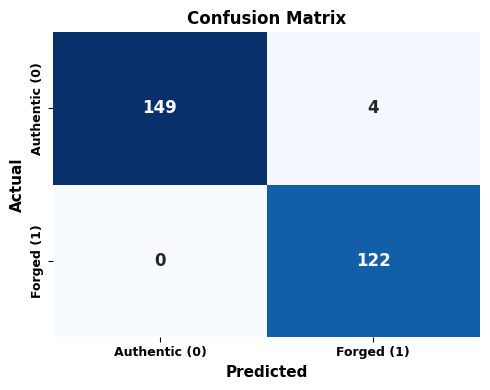

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            annot_kws={"weight": "bold", "size": 12},
            xticklabels=["Authentic (0)", "Forged (1)"],
            yticklabels=["Authentic (0)", "Forged (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
save_show("07_confusion_matrix")

In [ ]:
summary = pd.DataFrame({
    "Parameter": ["Dataset Size", "Train/Test Split", "Learning Rate", "Epochs Run",
                  "Final Weights", "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [len(df),
              f"{len(X_train)} / {len(X_test)}  (80/20)",
              LR,
              len(history),
              str(np.round(weights, 4)),
              round(bias, 4),
              f"{accuracy_score(y_test, y_pred):.4f}",
              f"{precision_score(y_test, y_pred):.4f}",
              f"{recall_score(y_test, y_pred):.4f}",
              f"{f1_score(y_test, y_pred):.4f}"]
})
print(summary.to_string(index=False))

print("\n===== Epoch-wise Learning =====")
print(history_df.to_string(index=False))

       Parameter                             Value
    Dataset Size                              1372
Train/Test Split               1097 / 275  (80/20)
   Learning Rate                              0.05
      Epochs Run                                20
   Final Weights [-0.8182 -0.9729 -0.8063 -0.032 ]
      Final Bias                             -0.35
        Accuracy                            0.9855
       Precision                            0.9683
          Recall                            1.0000
        F1-score                            0.9839

===== Epoch-wise Learning =====
 Epoch  Errors  Bias        w1        w2        w3        w4
     1      59 -0.15 -0.340125 -0.469045 -0.339095 -0.055178
     2      25 -0.20 -0.387678 -0.521068 -0.405337  0.017264
     3      20 -0.20 -0.401064 -0.563303 -0.458318 -0.018105
     4      19 -0.25 -0.441405 -0.597974 -0.500405  0.044547
     5      20 -0.25 -0.495447 -0.647528 -0.518603  0.051167
     6      17 -0.30 -0.513417 -0.638462

Task 7: Plots

Saved -> plots/05_training_error_vs_epoch.png


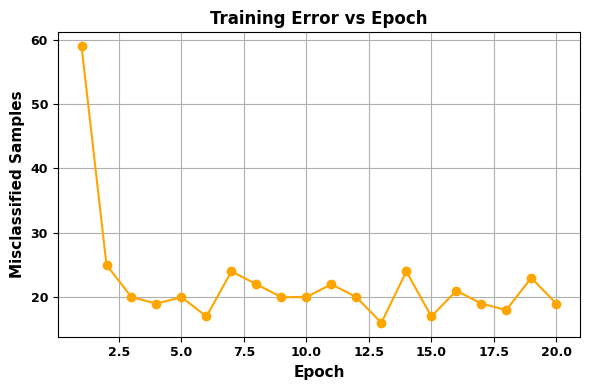

In [ ]:
epoch_list = [row["Epoch"] for row in history]
error_list = [row["Errors"] for row in history]

plt.figure(figsize=(6, 4))
plt.plot(epoch_list, error_list, marker="o", color="orange")
plt.title("Training Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.grid(True)
plt.tight_layout()
save_show("05_training_error_vs_epoch")

Saved -> plots/06_weight_evolution.png


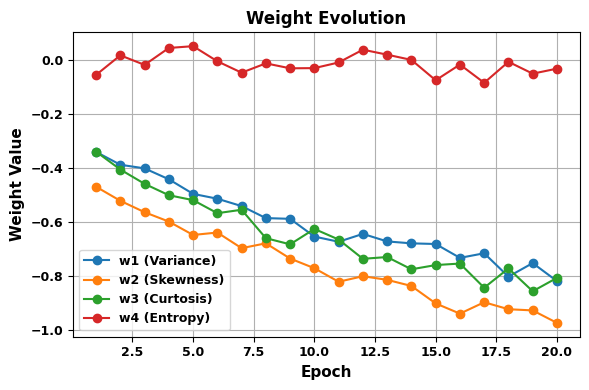

In [ ]:
plt.figure(figsize=(6, 4))
for i in range(X_train.shape[1]):
    w_list = [row[f"w{i+1}"] for row in history]
    plt.plot(epoch_list, w_list, marker="o", label=f"w{i+1} ({feats[i]})")
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_show("06_weight_evolution")

Saved -> plots/08_bias_evolution.png


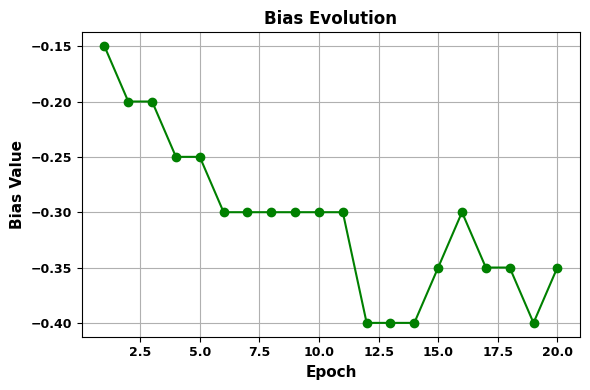

In [ ]:
bias_list = [row["Bias"] for row in history]
plt.figure(figsize=(6, 4))
plt.plot(epoch_list, bias_list, marker="o", color="green")
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.grid(True)
plt.tight_layout()
save_show("08_bias_evolution")

Additional Tasks

In [ ]:
sk = SkPerceptron(eta0=LR, max_iter=EPOCHS, random_state=42)
sk.fit(X_train, y_train)
sk_pred = sk.predict(X_test)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "From Scratch": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                     recall_score(y_test, y_pred), f1_score(y_test, y_pred)],
    "Scikit-learn": [accuracy_score(y_test, sk_pred), precision_score(y_test, sk_pred),
                     recall_score(y_test, sk_pred), f1_score(y_test, sk_pred)],
}).round(4)
print(comparison.to_string(index=False))

print("\nScratch weights :", np.round(weights, 4), " bias:", round(bias, 4))
print("Sklearn weights :", np.round(sk.coef_[0], 4), " bias:", np.round(sk.intercept_[0], 4))

   Metric  From Scratch  Scikit-learn
 Accuracy        0.9855        0.9600
Precision        0.9683        0.9173
   Recall        1.0000        1.0000
 F1-score        0.9839        0.9569

Scratch weights : [-0.8182 -0.9729 -0.8063 -0.032 ]  bias: -0.35
Sklearn weights : [-0.5772 -0.759  -0.5866 -0.1322]  bias: -0.15


Saved -> plots/09_learning_rate_comparison.png


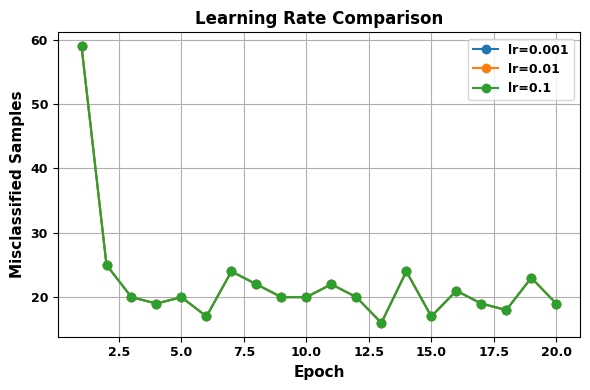

 Learning Rate  Epochs Run  Final Errors  Test Accuracy
         0.001          20            19         0.9855
         0.010          20            19         0.9855
         0.100          20            19         0.9855


In [ ]:
lr_rows = []
plt.figure(figsize=(6, 4))
for lr in [0.001, 0.01, 0.1]:
    w, b, h = train(X_train, y_train, lr=lr, epochs=EPOCHS)
    errs = [row["Errors"] for row in h]
    plt.plot(range(1, len(errs) + 1), errs, marker="o", label=f"lr={lr}")
    acc = accuracy_score(y_test, predict(X_test, w, b))
    lr_rows.append({"Learning Rate": lr, "Epochs Run": len(h),
                    "Final Errors": errs[-1], "Test Accuracy": round(acc, 4)})

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_show("09_learning_rate_comparison")

print(pd.DataFrame(lr_rows).to_string(index=False))

In [ ]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

w_xor, b_xor, h_xor = train(X_xor, y_xor, lr=0.1, epochs=50)
print("XOR predictions:", predict(X_xor, w_xor, b_xor), " | true:", y_xor)
print("Epochs run:", len(h_xor))
print("Final errors per epoch (last 5):", [r["Errors"] for r in h_xor][-5:])

XOR predictions: [1 1 0 0]  | true: [0 1 1 0]
Epochs run: 50
Final errors per epoch (last 5): [4, 4, 4, 4, 4]


2-feature perceptron -> weights: [-0.056  -0.0829], bias: -0.0, test accuracy: 0.8364
Saved -> plots/11_decision_boundary.png


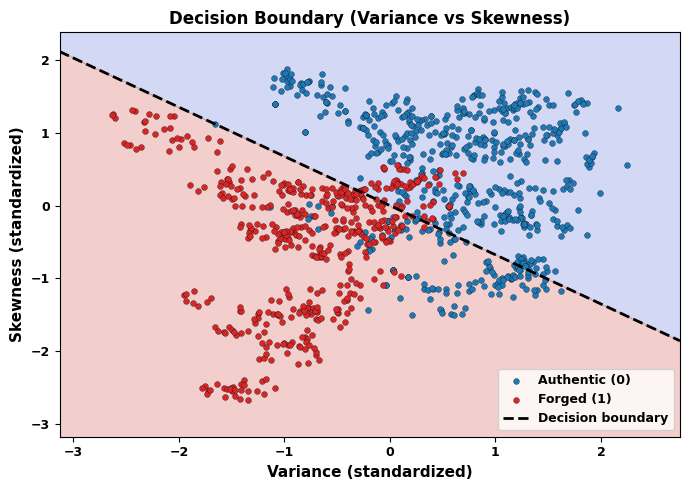

In [ ]:
pair = ["Variance", "Skewness"]
idx = [feats.index(f) for f in pair]

X2_train, X2_test = X_train[:, idx], X_test[:, idx]
w2, b2, h2 = train(X2_train, y_train, lr=LR, epochs=EPOCHS)
acc2 = accuracy_score(y_test, predict(X2_test, w2, b2))
print(f"2-feature perceptron -> weights: {np.round(w2, 4)}, bias: {round(b2, 4)}, "
      f"test accuracy: {acc2:.4f}")

x_min, x_max = X2_train[:, 0].min() - 0.5, X2_train[:, 0].max() + 0.5
y_min, y_max = X2_train[:, 1].min() - 0.5, X2_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = (np.c_[xx.ravel(), yy.ravel()] @ w2 + b2 >= 0).astype(int).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

for cls, colour, label in [(0, "tab:blue", "Authentic (0)"), (1, "tab:red", "Forged (1)")]:
    m = y_train == cls
    plt.scatter(X2_train[m, 0], X2_train[m, 1], s=18, c=colour, edgecolor="k",
                linewidth=0.2, label=label)

if abs(w2[1]) > 1e-9:
    x_line = np.array([x_min, x_max])
    plt.plot(x_line, -(w2[0] * x_line + b2) / w2[1], "k--", linewidth=2,
             label="Decision boundary")

plt.title("Decision Boundary (Variance vs Skewness)")
plt.xlabel("Variance (standardized)")
plt.ylabel("Skewness (standardized)")
plt.legend()
plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.tight_layout()
save_show("11_decision_boundary")

1.  Code the perceptron learning algorithm for OR, NOT, and AND gates using Python. Show the weights after each update. Plot the decision boundary after each weight update using Python built-in packages.

In [ ]:
def step(x):
    return 1 if x >= 0 else 0

def plot_all_updates(X, y, snapshots, title, ncols=4):
    n = len(snapshots)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows), squeeze=False)
    two_inputs = X.shape[1] == 2

    for k, ax in enumerate(axes.flatten()):
        if k >= n:
            ax.axis("off")
            continue
        w, b, label = snapshots[k]

        for i in range(len(X)):
            colour = "red" if y[i] == 0 else "blue"
            ax.scatter(X[i][0], X[i][1] if two_inputs else 0,
                       color=colour, s=80, zorder=3)

        if two_inputs and abs(w[1]) > 1e-6:
            x_line = np.linspace(-0.5, 1.5, 100)
            ax.plot(x_line, -(w[0] * x_line + b) / w[1], 'k-')
        elif abs(w[0]) > 1e-6:
            ax.axvline(x=-b / w[0], color='black')

        ax.set_xlim(-0.5, 1.5)
        if two_inputs:
            ax.set_ylim(-0.5, 1.5)
            ax.set_yticks([0, 1])
        else:
            ax.set_ylim(-0.5, 0.5)
            ax.set_yticks([])
        ax.set_xticks([0, 1])
        ax.grid(True)
        ax.set_title(f"{label}\nw={np.round(w, 2)}, b={b}", fontsize=9)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def perceptron_learning(X, y, lr=0.05, epochs=3, title="Gate"):
    w = np.zeros(X.shape[1])
    b = 0
    update = 1
    snapshots = []

    for epoch in range(epochs):
        error_count = 0
        for i in range(len(X)):
            output = step(np.dot(X[i], w) + b)
            error = y[i] - output
            if error != 0:
                w = w + lr * error * X[i]
                b = b + lr * error

                print(f"Update {update}: input {tuple(int(v) for v in X[i])}, "
                      f"error {int(error):+d}  ->  weights {w}, bias {b}")

                snapshots.append((w.copy(), b, f"Update {update}"))
                update += 1
                error_count += 1

        if error_count == 0:
            break

    print("Final Weights:", w)
    print("Final Bias:", b)
    print("Predictions:", [step(np.dot(x, w) + b) for x in X])

    plot_all_updates(X, y, snapshots, title)
    return w, b

Update 1: input (0, 0), error -1  ->  weights [0. 0.], bias -0.05
Update 2: input (1, 1), error +1  ->  weights [0.05 0.05], bias 0.0
Update 3: input (0, 0), error -1  ->  weights [0.05 0.05], bias -0.05
Update 4: input (0, 1), error -1  ->  weights [0.05 0.  ], bias -0.1
Update 5: input (1, 1), error +1  ->  weights [0.1  0.05], bias -0.05
Update 6: input (0, 1), error -1  ->  weights [0.1 0. ], bias -0.1
Update 7: input (1, 0), error -1  ->  weights [0.05 0.  ], bias -0.15000000000000002
Update 8: input (1, 1), error +1  ->  weights [0.1  0.05], bias -0.10000000000000002
Final Weights: [0.1  0.05]
Final Bias: -0.10000000000000002
Predictions: [0, 0, 0, 1]


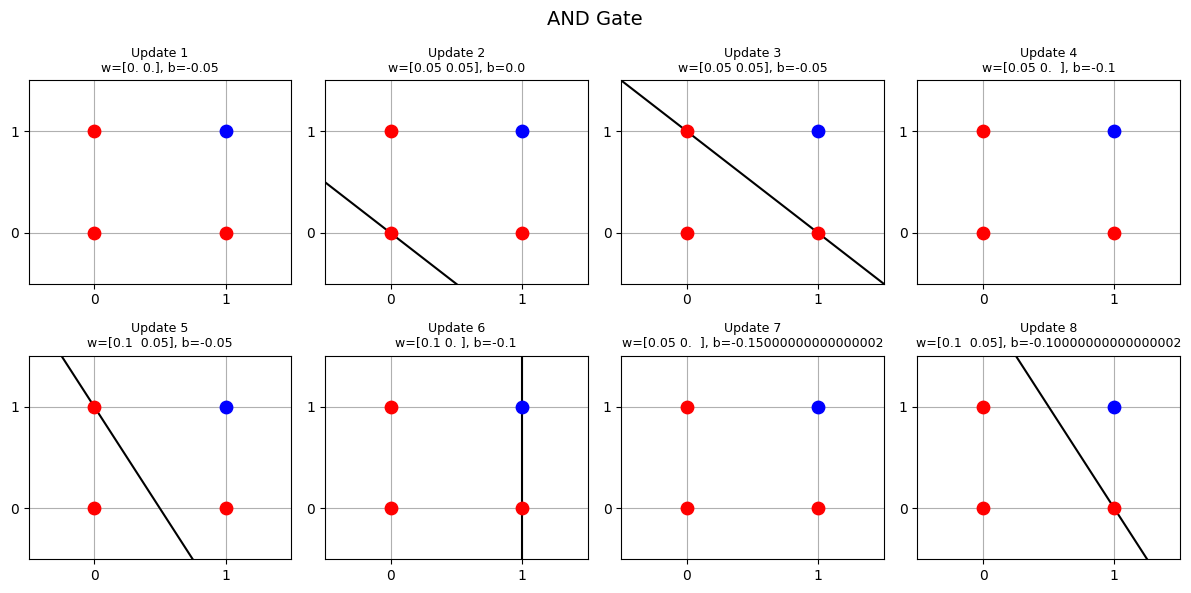

(array([0.1 , 0.05]), np.float64(-0.10000000000000002))

In [ ]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
perceptron_learning(X_and, y_and, title="AND Gate")

Update 1: input (0, 0), error -1  ->  weights [0. 0.], bias -0.05
Update 2: input (0, 1), error +1  ->  weights [0.   0.05], bias 0.0
Update 3: input (0, 0), error -1  ->  weights [0.   0.05], bias -0.05
Update 4: input (1, 0), error +1  ->  weights [0.05 0.05], bias 0.0
Update 5: input (0, 0), error -1  ->  weights [0.05 0.05], bias -0.05
Final Weights: [0.05 0.05]
Final Bias: -0.05
Predictions: [0, 1, 1, 1]


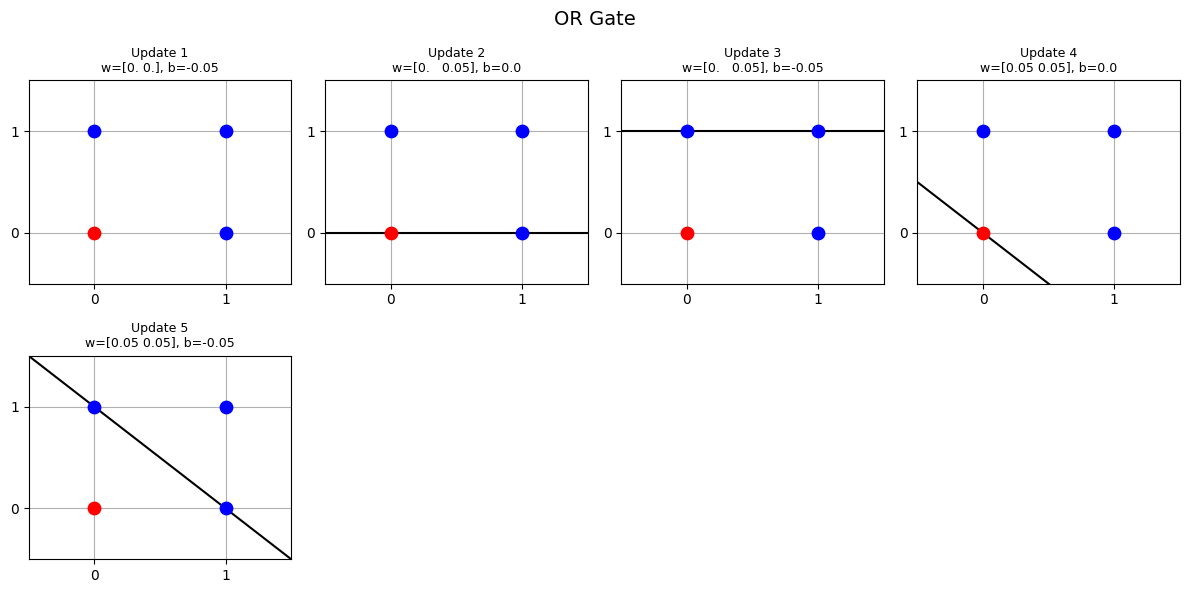

(array([0.05, 0.05]), np.float64(-0.05))

In [ ]:
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])
perceptron_learning(X_or, y_or, title = "OR Gate")

Update 1: input (1, 0), error -1  ->  weights [-0.05  0.  ], bias -0.05
Update 2: input (0, 0), error +1  ->  weights [-0.05  0.  ], bias 0.0
Final Weights: [-0.05  0.  ]
Final Bias: 0.0
Predictions: [1, 0]


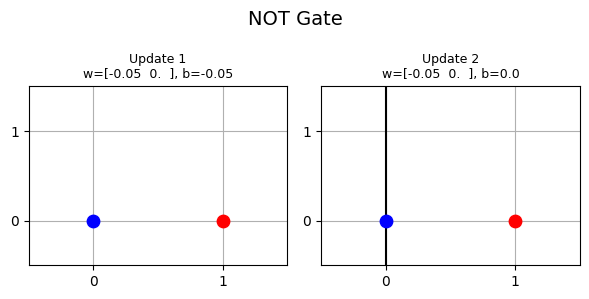

(array([-0.05,  0.  ]), np.float64(0.0))

In [ ]:
X_not = np.array([[0,0],[1,0]])
y_not = np.array([1,0])
perceptron_learning(X_not, y_not, title = "NOT Gate")